# UCB1's Blind Spot: Measuring How Much It Over-Explores Low Variance Arms

Stochastic bandit simulator to test what UCB1's confidence radius misses and evaluate performance gains from standard variance-sensitive modifications.

### The claim being tested

The confidence radius of the standard UCB algorithm is constructed via Hoeffding's inequality, and its rewards only lie in [0,1]. The algorithm does not take into account the variance of an arm's rewards and as a result has a tendency to over-explore arms with low variance. For such arms only a few pulls would be sufficient to achieve an accurate sample mean. For example, consider an arm that pays $\text{Bernoulli}(0.5)$, with variance 0.25, and another that pays something tightly clustered around 0.5 with variance 0.002. In the second case a few dozen pulls should be enough to rule it out.

However, this is obvious from simply looking at the formula for UCB. This notebook will test precisely:

1. How many pulls does UCB spend compared to that of a variance adaptive bound?
2. Does the usage of Empirical Bernstein bounds through UCB-V fix this issue?
3. Where does the improvement show up?

### Route

1. I will build the simulator from scratch: arms, environments, regret, a scalar and vectorised runner, and the classical baselines
2. Where $\sqrt{(2\ln t)/n}$ comes from, why it is blind to variance, and how many pulls that costs
3. UCB-V and Empirical Bernstein: the fix, its saturation point, and what each algorithm achieves
4. Findings, limitations, and what I would do next

### Reference

Aleksandrs Slivkins, *Introduction to Multi-Armed Bandits*, arXiv:1904.07272v8. Section numbers cited throughout refer to that text. Algorithm papers are listed at the end.

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from dataclasses import dataclass
import time

plt.rcParams.update({
    "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "legend.frameon": False,
    "axes.titlesize": 11, "axes.titleweight": "bold",
})

PALETTE = {"UCB1": "#111111", "UCB-V": "#3182bd", "EB-UCB": "#31a354"}
def colour(label):
    for k, v in PALETTE.items():
        if label.startswith(k):
            return v
    return "#bdbdbd"

print("numpy", np.__version__)

numpy 2.4.3


# Part 1. Building the simulator from scratch

## 1.1 The protocol

A stochastic bandit instance is $K$ unknown reward distributions $D_1, \dots, D_K$ over $[0,1]$. Algorithms that solve this bandit problem an arm $a_t$ at some time $t = 1,\dots,T$, known as the Time Horizon of the bandit problem. Doing so samples from the chosen arm's distribution, which is that action's reward. Since pulling an arm does not provide any information about the reward distributions of the other arms, a tradeoff arises between exploiting what we think is the optimal arm and exploring which of the arms is truly the optimal choice.

Two things need to exist before any algorithm can be evaluated:

1. **The environment**, which owns the true distributions and therefore the true means and variances.

2. **A notion of regret**, which compares the algorithm against the best fixed arm in hindsight.

## 1.2 One arm, Bayesian view

We start off by constructing a single Bernoulli arm with a Beta posterior. The arm is a distribution that determines the probability of a binary outcome and the posterior distribution determines the likelihood of the probability p that the Bernoulli arm takes on. Each observation nudges $(a, b)$, and the posterior mean $a/(a+b)$ converges to the true success probability.

true p = 0.300, posterior mean after 1000 observations = 0.3044


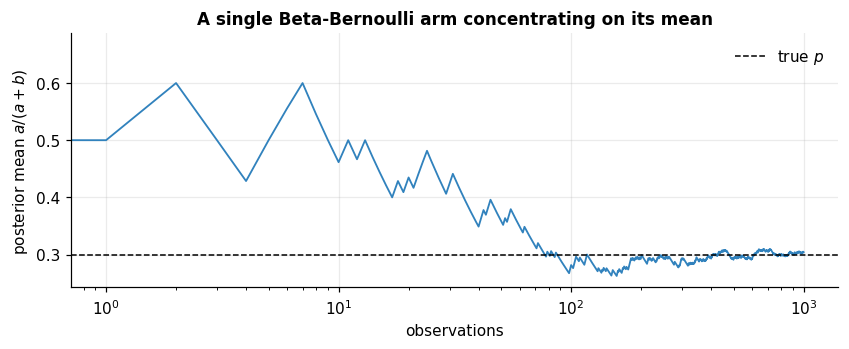

In [107]:
rng = np.random.default_rng(seed=42)

@dataclass
class OneArmBinomialBandit:
    a: float = 1.0
    b: float = 1.0

    def update(self, reward):
        if reward:
            self.a += 1
        else:
            self.b += 1

    def SampleP(self):
        return self.a / (self.a + self.b)

OABB = OneArmBinomialBandit()
evidence = rng.binomial(1, 0.3, size=1000)
trace = []
for e in evidence:
    OABB.update(e)
    trace.append(OABB.SampleP())

print(f"true p = 0.300, posterior mean after 1000 observations = {OABB.SampleP():.4f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(trace, color="#3182bd", lw=1.2)
ax.axhline(0.3, color="k", ls="--", lw=1, label="true $p$")
ax.set_xscale("log"); ax.set_xlabel("observations"); ax.set_ylabel(r"posterior mean $a/(a+b)$")
ax.set_title("A single Beta-Bernoulli arm concentrating on its mean")
ax.legend(); plt.show()

## 1.3 An interface for arms

Different reward families need different posteriors, however some of this information can be abstracted away as every posterior will have 3 methods. It will draw a sample of the mean, absorb an observation, and report the posterior mean.

In [110]:
from abc import ABC, abstractmethod

class BanditArm(ABC):
    @abstractmethod
    def sample(self, rng: np.random.Generator) -> float:
        # Sample from arm's expected reward
        pass
    @abstractmethod
    def update(self, reward: float) -> None:
        # Update distribution of the parameters of arm's distribution
        pass
    @property
    @abstractmethod
    def mean(self) -> float:
        # Mean expected reward
        pass


@dataclass
class BetaBernoulliArm(BanditArm):
    a: float = 1.0
    b: float = 1.0

    def __post_init__(self):
        if self.a <= 0 or self.b <= 0:
            raise ValueError("a and b must be positive")

    def update(self, reward: float) -> None:
        if reward not in (0, 1):
            raise ValueError(f"reward must be 0 or 1, got {reward!r}")
        if reward:
            self.a += 1
        else:
            self.b += 1

    def sample(self, rng): return rng.beta(self.a, self.b)

    @property
    def mean(self): return self.a / (self.a + self.b)


@dataclass
class GaussianArm(BanditArm):
    prior_mean: float = 0.0
    prior_var: float = 1.0
    obs_var: float = 1.0
    _post_mean: float = None
    _post_var: float = None

    def __post_init__(self):
        self._post_mean = self.prior_mean
        self._post_var = self.prior_var

    def update(self, reward: float) -> None:
        precision_prior = 1 / self._post_var
        precision_obs = 1 / self.obs_var
        new_precision = precision_prior + precision_obs
        self._post_mean = (precision_prior * self._post_mean + precision_obs * reward) / new_precision
        self._post_var = 1 / new_precision

    def sample(self, rng): return rng.normal(self._post_mean, np.sqrt(self._post_var))

    @property
    def mean(self): return self._post_mean


@dataclass
class PoissonArm(BanditArm):
    shape: float = 1.0
    rate: float = 1.0

    def update(self, reward: float) -> None:
        if reward < 0:
            raise ValueError(f"reward must be a non-negative count, got {reward!r}")
        self.shape += reward
        self.rate += 1

    def sample(self, rng): return rng.gamma(self.shape, 1 / self.rate)

    @property
    def mean(self): return self.shape / self.rate

## 1.4 Thompson sampling over a mixed arm set

Thompson sampling needs nothing from an arm beyond `sample`. It will draw one posterior sample per arm, play the argmax. Since the interface is uniform, the arms can be of different families at once (Slivkins §3.2).

In [113]:
class MultiArmedBandit:
    def __init__(self, *arms: BanditArm, rng: np.random.Generator | None = None):
        if not arms:
            raise ValueError("need at least one arm")
        self.arms = arms
        self.rng = rng or np.random.default_rng()

    def select_arm(self) -> int:
        # Python-level loop: each arm's .sample() dispatches to a different method body depending on its concrete type, 
        # so this cannot be vectorised.
        samples = [arm.sample(self.rng) for arm in self.arms]
        return int(np.argmax(samples))

    def update(self, arm_index: int, reward: float) -> None:
        self.arms[arm_index].update(reward)

    @property
    def means(self) -> list[float]:
        return [arm.mean for arm in self.arms]

    def best_arm(self) -> int:
        return int(np.argmax(self.means))


demo_rng = np.random.default_rng(0)
mab = MultiArmedBandit(BetaBernoulliArm(), BetaBernoulliArm(), BetaBernoulliArm(), rng=demo_rng)
truth = [0.30, 0.55, 0.50]
for _ in range(2000):
    a = mab.select_arm()
    mab.update(a, int(demo_rng.random() < truth[a]))

print("true means ", truth)
print("posterior means ", [round(m, 3) for m in mab.means])
print("best arm identified: ", mab.best_arm(), " (true best: 1)")
print("pulls per arm ", [round(arm.a + arm.b - 2) for arm in mab.arms])

true means  [0.3, 0.55, 0.5]
posterior means  [0.208, 0.525, 0.497]
best arm identified:  1  (true best: 1)
pulls per arm  [22, 1272, 706]


The results above show that Thompson sampling put all its budget on arm 1, and arm 0 quickly (gap $0.25$). It spent a moderate amount seperating arm 2 from arm 1 (gap $0.05$). The pull counts scale with $1/\Delta^2$. The question this project addresses is whether they should also scale with $\sigma^2$, and whether any algorithm manages it.

## 1.5 The environment

The environment allows the mean and the variance to be set independently and provides a ground truth against which algorithms can be scored. However, no policy ever sees this ground truth distribution, and only read their own pull counts and reward sums.

Bernoulli will not do: $\sigma^2 = \mu(1-\mu)$ is pinned by the mean. Two families that work:

| Family | Parameters | Mean | Variance |
|---|---|---|---|
| `BetaReward` | $\mu$, concentration $\nu$ | $\mu$ | $\mu(1-\mu)/(\nu+1)$ |
| `TwoPoint` | $\mu$, spread $c$ | $\mu$ | $c^2$ |

`BetaReward` is continuous, supported on $[0,1]$, and so every algorithm's boundedness assumption holds exactly. `from_var` inverts the variance formula so an instance can be specified as "mean $0.5$, variance $0.002$". The `TwoPoint` distribution simply marks the ceiling for the variance of a distribution on [0,1].

(Note: BanditArm.sample guesses the mean while RewardDist.sample draws an actual reward from the environment.)

In [116]:
class RewardDist(ABC):
    @abstractmethod
    def sample(self, rng, size): ...
    @property
    @abstractmethod
    def mean(self) -> float: ...
    @property
    @abstractmethod
    def var(self) -> float: ...
    def __repr__(self):
        return f"{type(self).__name__}(mean={self.mean:.3f}, var={self.var:.5f})"


@dataclass(frozen=True)
class Bernoulli(RewardDist):
    p: float
    def sample(self, rng, size): return (rng.random(size) < self.p).astype(float)
    @property
    def mean(self): return self.p
    @property
    def var(self): return self.p * (1 - self.p)


@dataclass(frozen=True)
class BetaReward(RewardDist):
    # Beta on [0,1] reparametrised by mean mu and concentration nu:
    # a = mu*nu, b = (1-mu)*nu, so var = mu(1-mu)/(nu+1).
    mu: float
    nu: float
    def sample(self, rng, size): return rng.beta(self.mu * self.nu, (1 - self.mu) * self.nu, size)
    @property
    def mean(self): return self.mu
    @property
    def var(self): return self.mu * (1 - self.mu) / (self.nu + 1.0)
    @staticmethod
    def from_var(mu, var):
        vmax = mu * (1 - mu)
        if not (0 < var < vmax):
            raise ValueError(f"variance must lie in (0, {vmax:.4f}) for mean {mu}")
        return BetaReward(mu, vmax / var - 1.0)


@dataclass(frozen=True)
class TwoPoint(RewardDist):
    mu: float
    spread: float
    def sample(self, rng, size):
        return self.mu + self.spread * np.where(rng.random(size) < 0.5, -1.0, 1.0)
    @property
    def mean(self): return self.mu
    @property
    def var(self): return self.spread ** 2


for d in [Bernoulli(0.5), BetaReward.from_var(0.5, 0.05), BetaReward.from_var(0.5, 0.002),
          TwoPoint(0.5, 0.5)]:
    print(d)

Bernoulli(p=0.5)
BetaReward(mu=0.5, nu=4.0)
BetaReward(mu=0.5, nu=124.0)
TwoPoint(mu=0.5, spread=0.5)


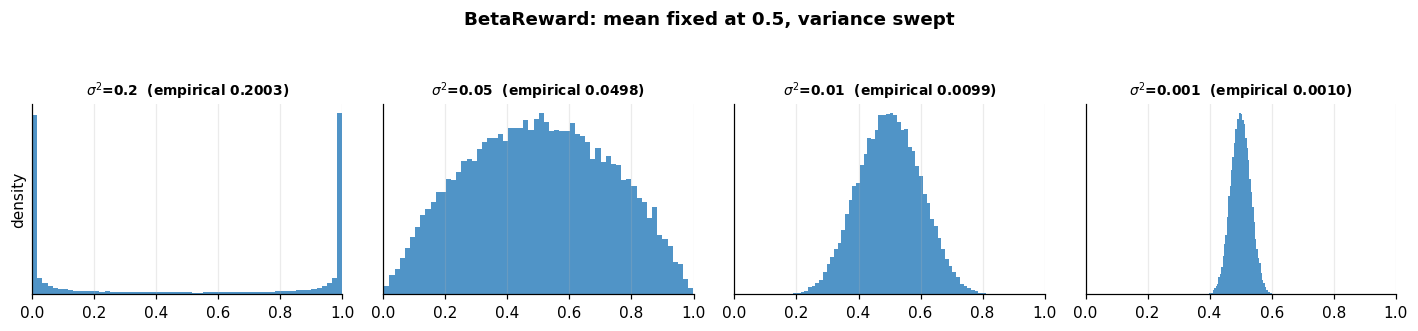

In [118]:
# Visual check that from_var does what it claims: same mean, four orders of magnitude of variance.
check_rng = np.random.default_rng(1)
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8))
for ax, v in zip(axes, [0.20, 0.05, 0.01, 0.001]):
    d = BetaReward.from_var(0.5, v)
    x = d.sample(check_rng, 40000)
    ax.hist(x, bins=60, color="#3182bd", alpha=0.85, density=True)
    ax.set_title(rf"$\sigma^2$={v}  (empirical {x.var():.4f})", fontsize=9)
    ax.set_xlim(0, 1); ax.set_yticks([])
axes[0].set_ylabel("density")
fig.suptitle("BetaReward: mean fixed at 0.5, variance swept", y=1.06, fontweight="bold")
plt.tight_layout(); plt.show()

## 1.6 Instances and regret

*Notation:* $K$ arms, horizon $T$, arm $a$ has mean $\mu(a)$ and variance $\sigma^2(a)$, the best arm is $a^*$ with mean $\mu^*$, and the gap is $\Delta(a) = \mu^* - \mu(a)$. <br>
$n_t(a)$ is the number of pulls of arm $a$ before round $t$ and $\bar\mu_t(a)$ is the empirical mean over those pulls.

An Instance bundles the arms and precomputes the true means, variances, and the index of the best arm, and the gaps $\Delta(a) = \mu^* - \mu(a)$.

We score with pseudo-regret (Slivkins §1.1):

$$\bar R(T) \;=\; \sum_{t=1}^{T} \Delta(a_t) \;=\; T\mu^* - \sum_{t=1}^T \mu(a_t).$$

This calculates the expected value of the gap between choosing a particular set of arms and choosing the optimal arm, rather than the gap between the optimal arm and the sample values retrieved from the reward distribution during a particular run. This isolates the noise from the algorithm's decision and removes the noise of sampling from the reward distribution.

In [121]:
class Instance:
    def __init__(self, *arms: RewardDist, name=""):
        self.arms = list(arms)
        self.name = name
        self.means = np.array([a.mean for a in arms])
        self.vars  = np.array([a.var for a in arms])
        self.best  = int(np.argmax(self.means))
        self.gaps  = self.means.max() - self.means

    @property
    def K(self): return len(self.arms)

    def reward_table(self, R, T, rng):
        # Shape (R, T, K) - One vectorised draw per arm is faster than T scalar draws
        # Same table can be handed to every algorithm, so they all face the same noise
        out = np.empty((R, T, self.K))
        for a, arm in enumerate(self.arms):
            out[:, :, a] = arm.sample(rng, (R, T))
        return out

    def __repr__(self):
        return (f"Instance({self.name}) K={self.K}\n"
                f"  means {np.round(self.means, 3)}\n"
                f"  vars  {np.round(self.vars, 5)}\n"
                f"  gaps  {np.round(self.gaps, 3)}")


demo = Instance(BetaReward.from_var(0.6, 0.05), *[BetaReward.from_var(0.5, 0.05)] * 4,
                name="uniform-variance K=5")
print(demo)

Instance(uniform-variance K=5) K=5
  means [0.6 0.5 0.5 0.5 0.5]
  vars  [0.05 0.05 0.05 0.05 0.05]
  gaps  [0.  0.1 0.1 0.1 0.1]


## 1.7 Two runners

Although a bandit simulation is described as a Python loop over $T$ rounds, scalar state, one arm chosen per round, it is too slow for the hundreds of replicates that are run below. The reason for this is that the bandit process is random, which means UCB1 might get a run where the first few pulls happen to look good.

There are two implementations. The scalar one is a reference as it is short and straightforward. The vectorised one runs $R$ independent replicates in lockstep, holding state as $(R, K)$ arrays, so one Python-level step advances all $R$ replicates at once. Section 1.9 checks
that they agree.

In [124]:
def run_scalar(index_fn, inst, T, seed):
    # index_fn(t, n, s, ss) returns a length-K vector of scores
    # arm with the highest score is played
    # n, s, ss are pull counts, reward sums and squared reward sums respectively
    rng = np.random.default_rng(seed)
    K = inst.K
    n = np.zeros(K); s = np.zeros(K); ss = np.zeros(K)
    regret = np.empty(T)
    total = 0.0
    for t in range(T):
        a = t if t < K else int(np.argmax(index_fn(t, n, s, ss)))
        r = float(inst.arms[a].sample(rng, 1)[0])
        n[a] += 1; s[a] += r; ss[a] += r * r
        total += inst.gaps[a]
        regret[t] = total
    return regret, n


def ucb1_index_scalar(t, n, s, ss, alpha=2.0):
    return s / n + np.sqrt(alpha * np.log(t) / n)

## 1.8 Vectorised framework

Every algorithm is known as an index policy, which essentially means that it scores every arm each round and plays the argmax.

- **Sufficient statistics:** `n`, `s` and `ss` are pull counts, reward sums and squared reward sums. Everything any algorithm below needs is a function of those three, which is why the same base class serves Hoeffding and Bernstein rules alike.
- The first $K$ rounds are a forced round robin, so every index is well defined from round $K$ onward and no division by zero occurs.
- Tie-breaking is randomised for fairness, as they are common early on.

In [127]:
def argmax_tiebreak(v, rng):
    return np.argmax(v + rng.random(v.shape) * 1e-12, axis=1)


class Policy(ABC):
    label = "policy"

    def __init__(self, K, T, R, rng):
        self.K, self.T, self.R, self.rng = K, T, R, rng
        self.n  = np.zeros((R, K))
        self.s  = np.zeros((R, K))
        self.ss = np.zeros((R, K))

    @property
    def muhat(self):
        return np.divide(self.s, self.n, out=np.zeros_like(self.s), where=self.n > 0)

    @property
    def varhat(self):
        m = self.muhat
        mean_sq = np.divide(self.ss, self.n, out=np.zeros_like(self.ss), where=self.n > 0)
        return np.maximum(mean_sq - m * m, 0.0)

    @abstractmethod
    def index(self, t): ...

    def select(self, t):
        if t < self.K:
            return np.full(self.R, t, dtype=np.intp)
        return argmax_tiebreak(self.index(t), self.rng)

    def update(self, arms, r):
        rows = np.arange(self.R)
        self.n[rows, arms]  += 1
        self.s[rows, arms]  += r
        self.ss[rows, arms] += r * r


def run(policy_cls, inst, T, R, seed=0, rewards=None, **kw):
    rng = np.random.default_rng(seed)
    if rewards is None:
        rewards = inst.reward_table(R, T, np.random.default_rng(seed + 10_000))
    pol = policy_cls(inst.K, T, R, rng, **kw)
    rows = np.arange(R)
    pulls = np.empty((R, T), dtype=np.intp)
    for t in range(T):
        a = pol.select(t)
        pol.update(a, rewards[rows, t, a])
        pulls[:, t] = a
    regret = np.cumsum(inst.gaps[pulls], axis=1)
    return dict(label=getattr(pol, "label", policy_cls.label),
                pulls=pulls, regret=regret, counts=pol.n, final=regret[:, -1])

## 1.9 The baseline algorithms

Four from Slivkins Chapter 1, plus a control.

| Algorithm | Rule | Regret | Slivkins |
|---|---|---|---|
| Uniform | pick at random | $O(T)$ | control |
| Explore-first | round robin for $NK$ rounds, then commit | $O(T^{2/3}(K\log T)^{1/3})$ | Thm 1.5 |
| $\varepsilon$-greedy | explore w.p. $\varepsilon_t \sim (K\log t/t)^{1/3}$ | $O(T^{2/3}(K\log T)^{1/3})$ | §1.2.1 |
| Successive Elimination | round robin over arms not yet ruled out | $O(\sqrt{KT\log T})$, $O(\sum_a \frac{\log T}{\Delta(a)})$ | Thm 1.10, 1.11 |
| UCB1 | $\bar\mu_t(a) + \sqrt{\alpha \log t / n_t(a)}$ | same as above | §1.3.3, Thm 1.16 |

In [130]:
class Uniform(Policy):
    label = "Uniform"
    def index(self, t): return self.rng.random((self.R, self.K))


class ExploreFirst(Policy):
    # Round robin for N pulls per arm, then commit to the empirical leader. 
    # Default N = (T/K)^{2/3} (log T)^{1/3} from Slivkins Thm 1.5.
    label = "Explore-first"
    def __init__(self, *a, N=None, **k):
        super().__init__(*a, **k)
        self.N = N if N is not None else max(
            1, int(round((self.T / self.K) ** (2 / 3) * np.log(self.T) ** (1 / 3))))
        self.label = f"Explore-first (N={self.N})"
    def index(self, t): return self.muhat
    def select(self, t):
        if t < self.N * self.K:
            return np.full(self.R, t % self.K, dtype=np.intp)
        return argmax_tiebreak(self.muhat, self.rng)


class EpsilonGreedy(Policy):
    label = "eps-greedy"
    def __init__(self, *a, c=1.0, **k):
        super().__init__(*a, **k); self.c = c
    def index(self, t): return self.muhat
    def select(self, t):
        if t < self.K:
            return np.full(self.R, t, dtype=np.intp)
        eps = min(1.0, self.c * (self.K * np.log(t) / t) ** (1 / 3))   # Slivkins section 1.2.1
        greedy = argmax_tiebreak(self.muhat, self.rng)
        rand = self.rng.integers(0, self.K, self.R)
        return np.where(self.rng.random(self.R) < eps, rand, greedy)


class SuccessiveElimination(Policy):
    # Round robin such that an arm is deactivated once its UCB drops below some other arm's LCB
    label = "Successive Elimination"
    def __init__(self, *a, **k):
        super().__init__(*a, **k)
        self.active = np.ones((self.R, self.K), bool)
        self.cursor = np.zeros(self.R, dtype=np.intp)
    def index(self, t): return self.muhat
    def select(self, t):
        if t < self.K:
            return np.full(self.R, t, dtype=np.intp)
        rad = np.sqrt(2 * np.log(self.T) / np.maximum(self.n, 1))
        ucb, lcb = self.muhat + rad, self.muhat - rad
        best_lcb = np.where(self.active, lcb, -np.inf).max(axis=1, keepdims=True)
        self.active &= (ucb >= best_lcb)
        self.active[np.arange(self.R), np.argmax(self.muhat, axis=1)] = True   # never empty
        order = (self.cursor[:, None] + np.arange(self.K)[None, :]) % self.K
        first = np.argmax(np.take_along_axis(self.active, order, axis=1), axis=1)
        arms = order[np.arange(self.R), first]
        self.cursor = (arms + 1) % self.K
        return arms


class UCB1(Policy):
    # Optimism under uncertainty. Slivkins Alg 1.5, radius from Hoeffding. index(a) = muhat(a) + sqrt(alpha * log t / n(a))
    # Radius does not depend on observed spread of the rewards.
    label = "UCB1"
    def __init__(self, *a, alpha=2.0, **k):
        super().__init__(*a, **k)
        self.alpha = alpha
        self.label = f"UCB1 (alpha={alpha:g})"
    def index(self, t):
        return self.muhat + np.sqrt(self.alpha * np.log(t) / self.n)

## 1.10 Checking the vectorised runner against the reference

If the two implementations are handed the same instance and the same algorithm, their mean regret should agree to within Monte Carlo error.

In [133]:
chk = Instance(BetaReward.from_var(0.6, 0.05), *[BetaReward.from_var(0.5, 0.05)] * 4, name="check")
T_chk, R_chk = 2000, 150

t0 = time.time()
scalar_final = np.array([run_scalar(ucb1_index_scalar, chk, T_chk, seed=1000 + i)[0][-1]
                         for i in range(R_chk)])
t_scalar = time.time() - t0

t0 = time.time()
vec = run(UCB1, chk, T_chk, R_chk, seed=7)
t_vec = time.time() - t0

ms, mv = scalar_final.mean(), vec["final"].mean()
se = np.sqrt(scalar_final.var(ddof=1) / R_chk + vec["final"].var(ddof=1) / R_chk)
print(f"scalar     regret {ms:7.2f}   ({t_scalar:5.2f}s for {R_chk} runs)")
print(f"vectorised regret {mv:7.2f}   ({t_vec:5.2f}s for {R_chk} runs)")
print(f"difference {ms - mv:+.2f}, combined standard error {se:.2f}  ->  "
      f"{abs(ms - mv) / se:.2f} standard errors apart")
print(f"speedup {t_scalar / t_vec:.0f}x at R={R_chk}, and it grows with R")
assert abs(ms - mv) < 3 * se, "implementations disagree"
print("PASS")

scalar     regret  113.10   ( 1.13s for 150 runs)
vectorised regret  112.44   ( 0.09s for 150 runs)
difference +0.66, combined standard error 0.69  ->  0.95 standard errors apart
speedup 12x at R=150, and it grows with R
PASS


## 1.11 The baseline picture

Two views. First the regret curves at a single horizon, then the exponent in $T$, which is what the theorems in the table actually constrain and which a single horizon cannot show.

In [135]:
base_inst = Instance(BetaReward.from_var(0.6, 0.08), *[BetaReward.from_var(0.5, 0.08)] * 4,
                     name="baseline K=5, gap 0.1")
T_b, R_b = 20000, 120
rw_b = base_inst.reward_table(R_b, T_b, np.random.default_rng(2024))

baselines = [Uniform, ExploreFirst, EpsilonGreedy, SuccessiveElimination, UCB1]
base_res = {}
for cls in baselines:
    r = run(cls, base_inst, T_b, R_b, seed=11, rewards=rw_b)
    base_res[r["label"]] = r
    print(f"{r['label']:26s} regret at T={T_b}: {r['final'].mean():8.1f} "
          f"+/- {2 * r['final'].std(ddof=1) / np.sqrt(R_b):.1f}")

Uniform                    regret at T=20000:   1599.8 +/- 0.9
Explore-first (N=541)      regret at T=20000:    216.4 +/- 0.0
eps-greedy                 regret at T=20000:    308.9 +/- 1.4
Successive Elimination     regret at T=20000:   1600.0 +/- 0.0
UCB1 (alpha=2)             regret at T=20000:    433.6 +/- 5.1


Explore-first (N=541)      regret at T=20000:    216.4 +/- 0.0


eps-greedy                 regret at T=20000:    308.9 +/- 1.4


Successive Elimination     regret at T=20000:   1600.0 +/- 0.0


UCB1 (alpha=2)             regret at T=20000:    433.6 +/- 5.1


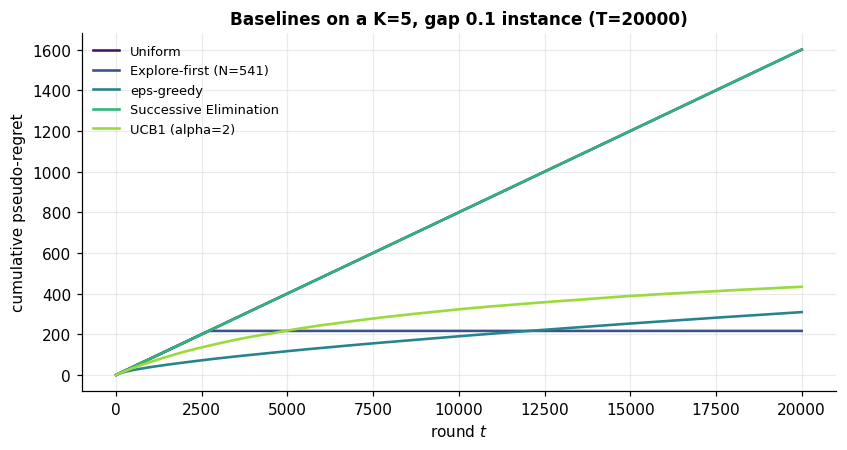

In [138]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
grid = np.arange(1, T_b + 1)
cols = plt.cm.viridis(np.linspace(0.05, 0.85, len(base_res)))
for (lab, r), c in zip(base_res.items(), cols):
    m = r["regret"].mean(axis=0)
    sd = 2 * r["regret"].std(axis=0, ddof=1) / np.sqrt(R_b)
    ax.plot(grid, m, label=lab, color=c, lw=1.7)
    ax.fill_between(grid, m - sd, m + sd, color=c, alpha=0.2, lw=0)
ax.set_xlabel("round $t$"); ax.set_ylabel("cumulative pseudo-regret")
ax.set_title(f"Baselines on a K=5, gap 0.1 instance (T={T_b})")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

At this single horizon the ranking is not the one the theory table predicts. Explore-first, which is $T^{2/3}$ asymptotically, beats UCB1 here, and Successive Elimination is indistinguishable from uniform. Some things to note about the performance of these algorithms are:

- Explore-first and Successive Elimination are given $T$ in advance, while the rest do not require a known time horizon. This has potential downsides, as guessing T too low will cause overexploration and the chance of choosing a suboptimal arm, while a T too high will waste too much time on exploration.
- Successive Elimination barely eliminates. Its radius $\sqrt{2\log T/n}$ carries a union bound over all arms and rounds, costing a factor $T^{-4}$ inside the probability. With $\Delta = 0.1$ the intervals do not separate until roughly $2\log T/(\Delta/2)^2 \approx 10^4$ pulls per arm, which exceeds the per-arm budget.

Sweeping the horizon separates them properly.

In [141]:
HORIZONS = [2000, 6000, 20000, 60000, 120000]
R_h = 40
sweep = {cls.label: [] for cls in baselines}

t0 = time.time()
for T in HORIZONS:
    rw = base_inst.reward_table(R_h, T, np.random.default_rng(3030 + T))
    for cls in baselines:
        sweep[cls.label].append(run(cls, base_inst, T, R_h, seed=19, rewards=rw)["final"].mean())
    del rw
print(f"horizon sweep done in {time.time() - t0:.0f}s\n")

Th = np.array(HORIZONS, float)
print(f"{'T':>8}" + "".join(f"{c.label:>24}" for c in baselines))
for i, T in enumerate(HORIZONS):
    print(f"{T:8d}" + "".join(f"{sweep[c.label][i]:24.1f}" for c in baselines))
print()
print(f"{'algorithm':<24}{'slope over full sweep':>23}{'| slope over the last doubling':>22}")
for cls in baselines:
    y = np.array(sweep[cls.label])
    sl = np.polyfit(np.log(Th), np.log(y), 1)[0]
    local = np.log(y[-1] / y[-2]) / np.log(Th[-1] / Th[-2])
    print(f"  {cls.label:<22}{sl:+23.2f}{local:+22.2f}")

horizon sweep done in 21s

       T                 Uniform           Explore-first              eps-greedy  Successive Elimination                    UCB1
    2000                   160.2                    42.9                    61.6                   160.0                   113.8
    6000                   479.5                    92.8                   132.9                   480.0                   241.0
   20000                  1598.6                   216.4                   309.0                  1600.0                   433.9
   60000                  4796.0                   466.4                   665.9                  3499.4                   609.3
  120000                  9598.8                   755.6                  1082.5                  3698.9                   707.1

algorithm                 slope over full sweep| slope over the last doubling
  Uniform                                 +1.00                 +1.00
  Explore-first                           +0.70   

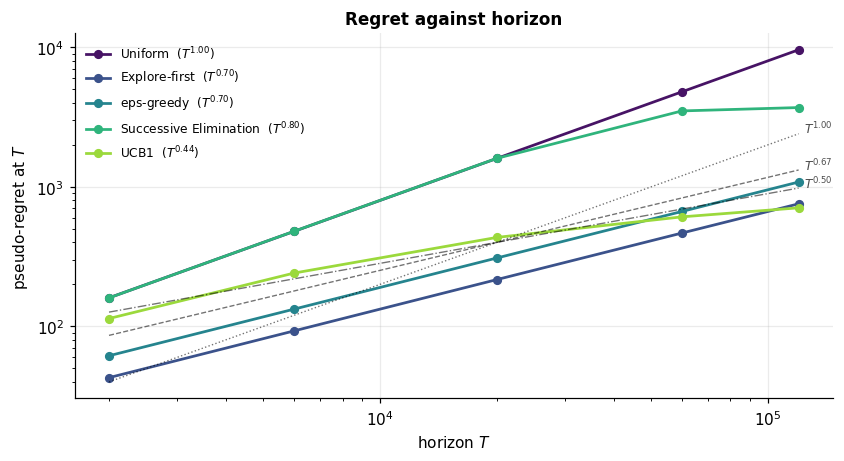

In [143]:
fig, ax = plt.subplots(figsize=(7.8, 4.3))
for (cls, c) in zip(baselines, cols):
    y = np.array(sweep[cls.label])
    sl = np.polyfit(np.log(Th), np.log(y), 1)[0]
    ax.loglog(Th, y, "o-", ms=5, lw=1.8, color=c, label=f"{cls.label}  ($T^{{{sl:.2f}}}$)")
for expo, style in [(1.0, ":"), (2 / 3, "--"), (0.5, "-.")]:
    ref = Th ** expo
    ax.loglog(Th, ref * (400 / ref[2]), style, color="k", lw=0.9, alpha=0.55)
    ax.annotate(rf"$T^{{{expo:.2f}}}$", (Th[-1] * 1.03, (Th[-1] ** expo) * (400 / ref[2])),
                fontsize=8, alpha=0.7)
ax.set_xlabel("horizon $T$"); ax.set_ylabel("pseudo-regret at $T$")
ax.set_title("Regret against horizon")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

In the graph above, the slope is the exponent of T with which regret scales for each algorithm. Uniform sits exactly on $T^1$, Explore-first and $\varepsilon$-greedy come out near $T^{2/3}$, and their local slopes are stable.

The columns of the slope of the overall curve and the curve over the last doubling differ for the two adaptive algorithms, which shows that these logarithmic curves do not have fixed exponents. The decay in these exponents is signature of logarithmic regret and for UCB1 shows improvement over a longer time horizon with respect to the other algorithms' performance.

UCB1 is the benchmark for the rest of the notebook. The two quantities that determine its curve are its horizon, through log(t), and its gap, through the constant in front of it. The spread of the rewards does not appear anywhere in the algorithm.

# Part 2. Diagnosing the blind spot

## 2.1 Where the radius comes from

UCB1's confidence radius comes from Hoeffding's inequality. Hoeffding's inequality provides an upper bound on the probability that the sum of independent random variables differs from its mean by a certain amount. Setting these independent variables as the pull of a particular arm at time $i = 1, \dots, t$ divided by the number of pulls t allows you to use this inequality to bound the probability that the sample mean differs from the actual mean by an arbitrary amount.

For independent $X_1, \dots, X_n$ taking values in an interval of width $b$, with mean $\mu$ and empirical mean $\bar\mu$ (Slivkins Appendix A, Thm A.1):

$$\Pr\!\big[\,|\bar\mu - \mu| > r\,\big] \;\le\; 2\exp\!\Big(\frac{-2nr^2}{b^2}\Big).$$

Set the right side to $2/T^4$, solve for $r$, and take a union bound over arms and rounds, which states that the probability of the union of events is less than the sum of the individual events. Choosing r to be the following:

$$r_t(a) = \sqrt{\frac{2\log T}{n_t(a)}},$$

This bounds the probability of the true mean being within r of the emprical mean (known as the clean event) by $2/T^4$ and bounding over every arm $K\leq T$ and every sample count $T$ produces:

$$\Pr[\mathcal{E}] < \tfrac{2}{T^2}.$$
$$\Pr[\mathcal{E}] \ge 1 - \tfrac{2}{T^2}.$$

The only property of the distribution that enters is $b$, the width of its support. A $\text{Bernoulli}(1/2)$ arm and an arm paying $0.5 \pm 0.001$ both have $b = 1$ as far as this bound is concerned, so UCB1 assigns them the same radius after the same number of pulls. The second arm is essentially deterministic and could be identified in a handful of samples.

## 2.2 What the radius should be

Bernstein's inequality fixes this, keeping the variance at:

$$\Pr\!\big[\,|\bar\mu - \mu| > r\,\big] \;\le\; 2\exp\!\Big(\frac{-nr^2}{2\sigma^2 + \tfrac{2}{3}br}\Big)
\qquad\Longrightarrow\qquad
r \;\approx\; \underbrace{\sqrt{\frac{2\sigma^2 L}{n}}}_{\text{variance term}} \;+\; \underbrace{\frac{cbL}{n}}_{\text{range term}},$$

where $L = \log(1/\delta)$. When $\sigma^2 \ll b^2$ the variance term is far smaller than Hoeffding's $\sqrt{2b^2L/n}$. But the range term never disappears. It decays like $1/n$ rather than $1/\sqrt{n}$, so it is negligible for small $n$ and eventually takes over.

In [147]:
L = 10.0     # log(1/delta), roughly log t at t ~ 2e4
b, c_rng = 1.0, 3.0
n_grid = np.logspace(0.5, 4.2, 300)

def n_hoeffding(target, L=L):
    return 2 * L / target ** 2

def n_bernstein(target, sig2, L=L, c=c_rng, b=b):
    # Number of pulls for r to fall below target, by bisection.
    lo, hi = np.full(np.shape(sig2), 1.0), np.full(np.shape(sig2), 1e9)
    for _ in range(80):
        mid = np.sqrt(lo * hi)
        too_big = np.sqrt(2 * sig2 * L / mid) + c * b * L / mid > target
        lo, hi = np.where(too_big, mid, lo), np.where(too_big, hi, mid)
    return hi

print("Pulls needed to shrink the confidence radius below a target, at L = 10.\n")
print(f"{'target radius':>14}{'variance':>10}{'UCB1 (Hoeffding)':>19}{'Bernstein':>12}{'waste factor':>14}")
print("-" * 70)
for tgt in [0.10, 0.05, 0.03]:
    for v in [0.24, 0.02, 0.002]:
        nh, nb = n_hoeffding(tgt), float(n_bernstein(tgt, np.array(v)))
        print(f"{tgt:14.2f}{v:10.3f}{nh:19.0f}{nb:12.0f}{nh / nb:13.1f}x")
    print()

Pulls needed to shrink the confidence radius below a target, at L = 10.

 target radius  variance   UCB1 (Hoeffding)   Bernstein  waste factor
----------------------------------------------------------------------
          0.10     0.240               2000         989          2.0x
          0.10     0.020               2000         431          4.6x
          0.10     0.002               2000         337          5.9x

          0.05     0.240               8000        3000          2.7x
          0.05     0.020               8000        1000          8.0x
          0.05     0.002               8000         706         11.3x

          0.03     0.240              22222        7194          3.1x
          0.03     0.020              22222        1925         11.5x
          0.03     0.002              22222        1234         18.0x



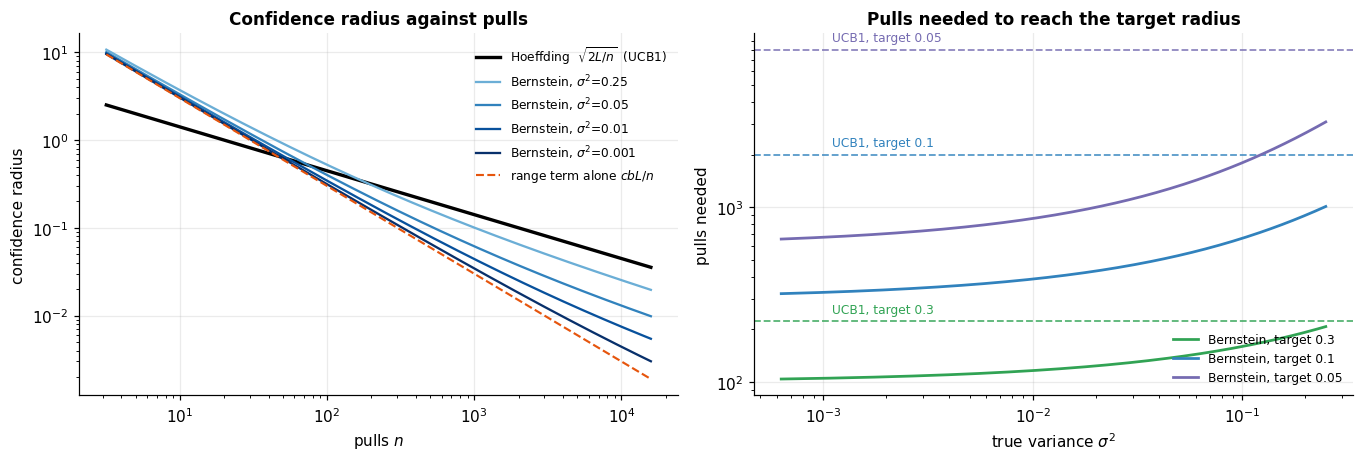

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))

ax = axes[0]
ax.loglog(n_grid, np.sqrt(2 * b**2 * L / n_grid), color="k", lw=2.2,
          label=r"Hoeffding  $\sqrt{2L/n}$  (UCB1)")
for v, col in zip([0.25, 0.05, 0.01, 0.001], ["#6baed6", "#3182bd", "#08519c", "#08306b"]):
    ax.loglog(n_grid, np.sqrt(2 * v * L / n_grid) + c_rng * b * L / n_grid, color=col, lw=1.5,
              label=rf"Bernstein, $\sigma^2$={v}")
ax.loglog(n_grid, c_rng * b * L / n_grid, "--", color="#e6550d", lw=1.4,
          label=r"range term alone $cbL/n$")
ax.set_xlabel("pulls $n$"); ax.set_ylabel("confidence radius")
ax.set_title("Confidence radius against pulls")
ax.legend(fontsize=8)

ax = axes[1]
v_grid = np.logspace(-3.2, np.log10(0.25), 200)
for tgt, col in zip([0.3, 0.1, 0.05], ["#31a354", "#3182bd", "#756bb1"]):
    ax.loglog(v_grid, n_bernstein(tgt, v_grid), color=col, lw=1.8, label=rf"Bernstein, target {tgt}")
    ax.axhline(n_hoeffding(tgt), color=col, ls="--", lw=1.2, alpha=0.8)
    ax.annotate(f"UCB1, target {tgt}", (1.1e-3, n_hoeffding(tgt) * 1.12), fontsize=8, color=col)
ax.set_xlabel(r"true variance $\sigma^2$"); ax.set_ylabel("pulls needed")
ax.set_title("Pulls needed to reach the target radius")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

The graph on the left hand side shows the quantitative difference between the number of pulls needed to reach a particular confidence radius. Given a reward distribution bounded on [0,1] the highest possible variance it can achieve is 0.25. We can see that Bernstien outperforms UCB in terms of reaching a lower confidence radius at about 200 pulls for reward distributions of all variances (bounded by [0,1]).

To illustrate the point further, the table shows that at $\sigma^2 = 0.002$ and a target radius of $0.03$, UCB1 needs on the order of ten times more samples than a variance-aware bound to reach the same confidence.

The gain is the vertical distance between the solid and dashed lines at small $\sigma^2$. The limit is that the solid lines stop falling: below some variance the range term is all that is left, and it does not care about $\sigma^2$ either.

## 2.3 Translating radius into regret

On the clean event, a suboptimal arm keeps getting played only while its confidence interval overlaps the best arm's, which requires its radius to exceed roughly $\Delta(a)$ (Slivkins §1.3.3, eq. 1.10). Setting $r = \Delta(a)$ and solving for $n$:

| Radius | Pulls of a suboptimal arm | Regret contribution $\Delta \cdot n$ |
|---|---|---|
| $\sqrt{2L/n}$ (Hoeffding, UCB1) | $n \approx \dfrac{2L}{\Delta^2}$ | $\dfrac{2L}{\Delta}$ |
| $\sqrt{2\sigma^2 L/n} + cL/n$ (Bernstein) | $n \approx \dfrac{2\sigma^2 L}{\Delta^2} + \dfrac{cL}{\Delta}$ | $\dfrac{2\sigma^2 L}{\Delta} + cL$ |

- UCB1's regret per suboptimal arm scales as $1/\Delta$, and does not move with $\sigma^2$ at all.
- A Bernstein algorithm on a low-variance instance has the first term vanish, leaving $cL$, which is constant in $\Delta$.

So the sharpest available test is not "does regret fall when variance falls". It is: **hold the variance
low and sweep the gap.** UCB1 should trace a line of slope $-1$ on a log-log plot against $\Delta$; a
Bernstein algorithm should trace a flat line.

## 2.4 Confirming the blind spot

UCB1's radius has no variance component, so it cannot adapt to the variance by construction. That does not necessarily mean that its regret moves with variance since $\sigma^2$ can still control how noisy the empirical mean is and thereby which arm the index picks. I first verify the claim that UCB1's regret is constant when compared with different variances:

In [152]:
SIGMAS = [0.24, 0.15, 0.08, 0.04, 0.02, 0.01, 0.005, 0.002]

def variance_instance(sig2, K=5, mu_star=0.6, mu_bad=0.5):
    v_star = min(sig2, 0.95 * mu_star * (1 - mu_star))
    return Instance(BetaReward.from_var(mu_star, v_star),
                    *[BetaReward.from_var(mu_bad, sig2)] * (K - 1),
                    name=f"K={K}, gap={mu_star - mu_bad:.2f}, sig2={sig2}")

T_d, R_d = 8000, 200
diag = []
for v in SIGMAS:
    inst = variance_instance(v)
    rw = inst.reward_table(R_d, T_d, np.random.default_rng(int(v * 1e6) + 5))
    r = run(UCB1, inst, T_d, R_d, seed=13, rewards=rw)
    diag.append((v, r["final"].mean(), 2 * r["final"].std(ddof=1) / np.sqrt(R_d),
                 r["counts"][:, 1:].mean()))

print(f"{'sigma^2':>9} {'regret':>10} {'+/-':>6} {'pulls per bad arm':>20}")
for v, m, e, bp in diag:
    print(f"{v:9.3f} {m:10.1f} {e:6.1f} {bp:20.1f}")

v_arr = np.array([d[0] for d in diag]); r_arr = np.array([d[1] for d in diag])
print(f"\nvariance swept by a factor of {v_arr.max() / v_arr.min():.0f}x")
print(f"UCB1 regret moved by a factor of {r_arr.max() / r_arr.min():.2f}x")

  sigma^2     regret    +/-    pulls per bad arm
    0.240      283.4    4.5                708.4
    0.150      287.2    3.8                718.1
    0.080      282.5    2.8                706.3
    0.040      285.6    2.0                714.0
    0.020      285.6    1.4                714.1
    0.010      284.8    1.0                712.0
    0.005      284.0    0.7                710.1
    0.002      284.3    0.4                710.7

variance swept by a factor of 120x
UCB1 regret moved by a factor of 1.02x


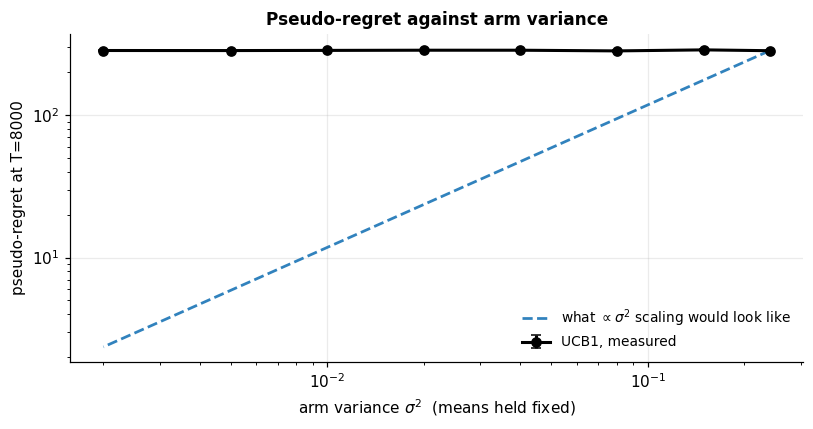

In [154]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.errorbar(v_arr, r_arr, yerr=np.array([d[2] for d in diag]),
            marker="o", color="k", lw=2, capsize=3, label="UCB1, measured")
ax.plot(v_arr, r_arr[0] * v_arr / v_arr[0], "--", color="#3182bd", lw=1.8,
        label=r"what $\propto\sigma^2$ scaling would look like")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"arm variance $\sigma^2$  (means held fixed)")
ax.set_ylabel(f"pseudo-regret at T={T_d}")
ax.set_title("Pseudo-regret against arm variance")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

The graph confirms that the regret for UCB1 is independent of arm variance, a fix for which is introduced and has its benefits quantified in part 3.

# Part 3. Quantifying the fix

The two algorithms I use both estimate variance via empirical Bernstein inequalities.

## 3.1 UCB-V

Audibert, Munos and Szepesvari (2009), *Exploration-exploitation tradeoff using variance estimates in multi-armed bandits*. Their empirical Bernstein radius:
$$r_t(a) \;=\; \sqrt{\frac{2\,\hat\sigma^2_t(a)\,\mathcal{E}_t}{n_t(a)}} \;+\; \frac{3\,c\,b\,\mathcal{E}_t}{n_t(a)},
\qquad \mathcal{E}_t = \zeta \log t .$$

where the reward distribution is bounded by [0,b] and $\mathcal{E}_t$ refers to an exploration function that governs how aggresively the algorithm decides to explore. Note that it scales logarithmically with t and has a tunable $\zeta$ parameter. Increasing this parameter results in wider confidence intervals and hence more exploration.

Their Theorem 4 sets $c = 1$ and $\mathcal{E}_t = \zeta\log t$ with $\zeta = 1.2$,

$$\mathbb{E}[R_n] \;\le\; 10 \sum_{k\,:\,\Delta_k > 0}\left(\frac{\sigma_k^2}{\Delta_k} + 2b\right)\log n,$$

The c and $\zeta$ parameters are set to the same values for this notebook as well, since tuning either would improve UCB-V's results while UCB1 gets no such tuning, resulting in an unfair comparison.

$$\mathbb{E}[T_k(n)] \;\le\; 10\left(\frac{\sigma_k^2}{\Delta_k^2} + \frac{2b}{\Delta_k}\right)\log n .$$

Comparing UCB1's $\frac{8\log T}{\Delta(a)^2}$ (Auer et al. 2002, Theorem 1) shows that the first term is smaller by roughly $\sigma^2/b^2$. The second term does not shrink with the variance, and it scales as $1/\Delta$ rather than $1/\Delta^2$. Experiment C measures how much that change of exponent is worth.

## 3.2 Empirical Bernstein UCB

The Maurer and Pontil (2009) bound used directly as a radius. For $X_i \in [0, b]$, with probability at least $1 - \delta$,

$$\mu \;\le\; \bar\mu + \sqrt{\frac{2\hat V_n \log(1/\delta)}{n}} + \frac{7b\log(1/\delta)}{3(n-1)},$$

with $\hat V_n$ the *unbiased* sample variance. Taking $\delta_t = t^{-3}$ makes it hold simultaneously over
time by a union bound, since $\sum_t t^{-3}$ converges.

Same structure, different constants. It is included as a second data point so that anything observed below
cannot be blamed on one paper's choice of $\zeta$.

In [158]:
class UCBV(Policy):
    label = "UCB-V"
    def __init__(self, *a, zeta=1.2, c=1.0, b=1.0, **k):
        super().__init__(*a, **k)
        self.zeta, self.c, self.b = zeta, c, b
    def index(self, t):
        E = self.zeta * np.log(t)
        return self.muhat + np.sqrt(2 * self.varhat * E / self.n) + 3 * self.c * self.b * E / self.n


class EmpiricalBernstein(Policy):
    label = "EB-UCB"
    def __init__(self, *a, b=1.0, **k):
        super().__init__(*a, **k)
        self.b = b
    def index(self, t):
        L = 3 * np.log(t)
        nm1 = np.maximum(self.n - 1, 1.0)
        V = self.varhat * self.n / nm1
        return self.muhat + np.sqrt(2 * V * L / self.n) + 7 * self.b * L / (3 * nm1)


ALGOS = [UCB1, UCBV, EmpiricalBernstein]

## 3.3 Experiment A: sweeping the variance

The same sweep as section 2.4, now with the two Bernstein algorithms alongside. Means fixed at $\mu^* = 0.6$ and $\mu = 0.5$ for four suboptimal arms, resulting in $\Delta = 0.1$ throughout. All algorithms share a pre-drawn reward table, so they face identical draws wherever they make identical choices.

In [161]:
T1, R1 = 8000, 200
EA = {cls.label: {"regret": [], "se": [], "bad_pulls": []} for cls in ALGOS}

t0 = time.time()
for v in SIGMAS:
    inst = variance_instance(v)
    rw = inst.reward_table(R1, T1, np.random.default_rng(int(v * 1e6) + 31))
    for cls in ALGOS:
        r = run(cls, inst, T1, R1, seed=41, rewards=rw)
        EA[cls.label]["regret"].append(r["final"].mean())
        EA[cls.label]["se"].append(r["final"].std(ddof=1) / np.sqrt(R1))
        EA[cls.label]["bad_pulls"].append(r["counts"][:, 1:].mean())

hdr = f"{'sigma^2':>8}" + "".join(f"{c.label:>12}" for c in ALGOS)
print(hdr); print("-" * len(hdr))
for i, v in enumerate(SIGMAS):
    print(f"{v:8.3f}" + "".join(f"{EA[c.label]['regret'][i]:12.1f}" for c in ALGOS))

 sigma^2        UCB1       UCB-V      EB-UCB
--------------------------------------------
   0.240       285.7       268.0       415.5
   0.150       283.4       234.8       381.4
   0.080       285.2       203.2       343.4
   0.040       284.9       178.2       311.8
   0.020       283.6       160.5       286.7
   0.010       283.8       149.1       268.8
   0.005       284.3       141.9       257.4
   0.002       284.2       134.8       246.1


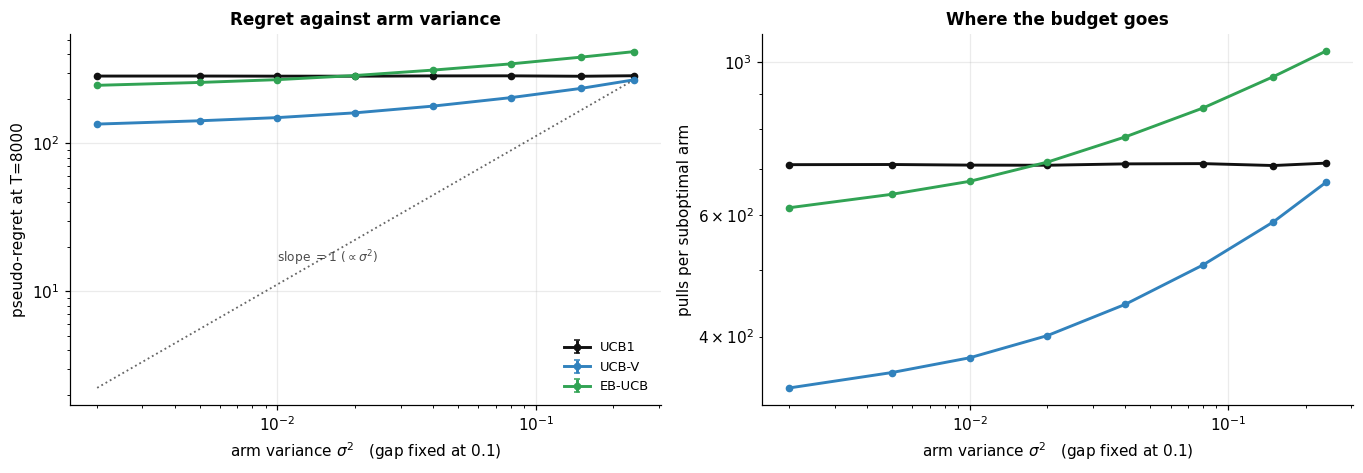

log-log slope of regret against sigma^2 (1.0 would be fully variance-proportional):
  UCB1     +0.001
  UCB-V    +0.143
  EB-UCB   +0.111


In [162]:
sig = np.array(SIGMAS)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for cls in ALGOS:
    lab = cls.label
    axes[0].errorbar(sig, EA[lab]["regret"], yerr=2 * np.array(EA[lab]["se"]),
                     marker="o", ms=4, lw=1.9, color=colour(lab), label=lab, capsize=2)
    axes[1].plot(sig, EA[lab]["bad_pulls"], marker="o", ms=4, lw=1.9, color=colour(lab))
for ax, ylab, ttl in [(axes[0], f"pseudo-regret at T={T1}", "Regret against arm variance"),
                      (axes[1], "pulls per suboptimal arm", "Where the budget goes")]:
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"arm variance $\sigma^2$   (gap fixed at 0.1)")
    ax.set_ylabel(ylab); ax.set_title(ttl)
ref = np.array(EA["UCB-V"]["regret"])[0] * sig / sig[0]
axes[0].plot(sig, ref, ":", color="k", lw=1.2, alpha=0.6)
axes[0].annotate(r"slope $=1$ ($\propto\sigma^2$)", (sig[-3], ref[-3] * 1.4), fontsize=8, alpha=0.7)
axes[0].legend(fontsize=8.5)
plt.tight_layout(); plt.show()

print("log-log slope of regret against sigma^2 (1.0 would be fully variance-proportional):")
for cls in ALGOS:
    print(f"  {cls.label:<8} {np.polyfit(np.log(sig), np.log(EA[cls.label]['regret']), 1)[0]:+.3f}")

UCB1 is flat just as Part 2 established. The variance adaptation UCB-V and EB-UCB is real as their pseudo regret responds to changes in arm variance, however, neither has a slope that comes close to 1. Across a 120-fold drop in variance their regret falls by about a factor
of two, not a factor of a hundred. This is due to the range term.

## 3.4 Experiment B: why the response saturates

For UCB-V the two parts of the radius are equal when

$$\sqrt{\frac{2\sigma^2\mathcal{E}}{n}} \;=\; \frac{3cb\,\mathcal{E}}{n}
\qquad\Longleftrightarrow\qquad
n^\star \;=\; \frac{9c^2b^2\,\mathcal{E}}{2\sigma^2}, \qquad \mathcal{E} = \zeta\log t .$$

Below $n^\star$ the $1/n$ range term is the larger term, which means the variance term is not contributing as much. Since $n^\star$ grows as $\sigma^2$ falls, a higher pull count is needed for the variance term to drive the size of the confidence radius, however the whole point of the variance adaptation of this algorithm is to discard low variance arms with a smaller number of pulls. Plotting $n^\star$ against the pull counts actually observed in Experiment A settles whether the algorithm ever gets into the variance-dominated regime at all.

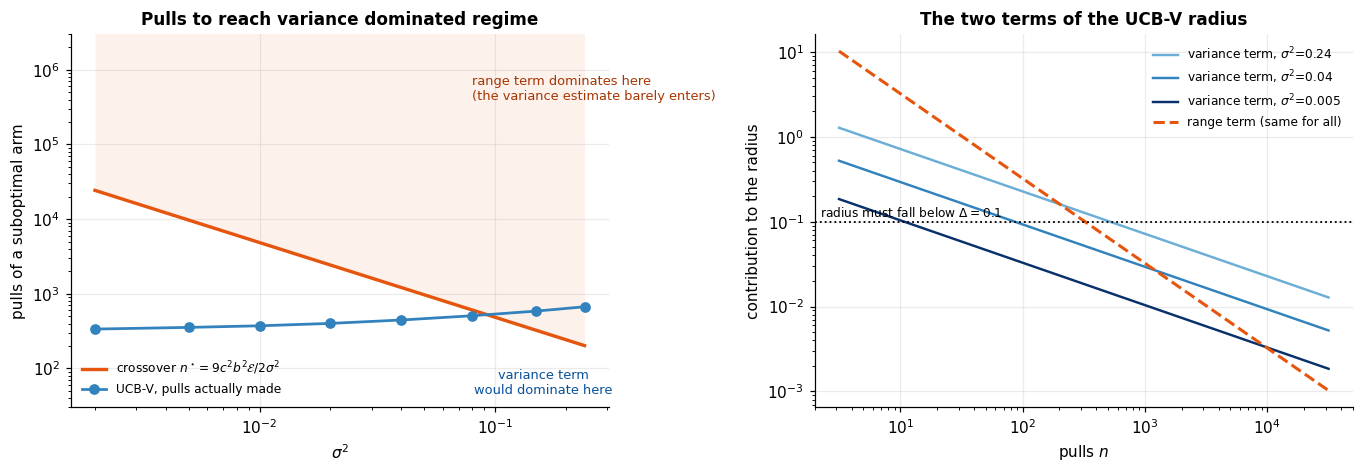

In [164]:
zeta, cc, bb = 1.2, 1.0, 1.0
E_t = zeta * np.log(T1)
n_star = 9 * cc**2 * bb**2 * E_t / (2 * sig)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
ax.loglog(sig, n_star, color="#e6550d", lw=2.2, label=r"crossover $n^\star = 9c^2b^2\mathcal{E}/2\sigma^2$")
ax.loglog(sig, EA["UCB-V"]["bad_pulls"], "o-", color=PALETTE["UCB-V"], lw=1.8,
          label="UCB-V, pulls actually made")
ax.fill_between(sig, n_star, 1e7, color="#e6550d", alpha=0.08, lw=0)
ax.set_ylim(30, 3e6)
ax.annotate("range term dominates here\n(the variance estimate barely enters)",
            (sig[2], 4e5), fontsize=8.5, color="#a63603")
ax.annotate("variance term\nwould dominate here", (0.16, 45), fontsize=8.5, color="#08519c", ha="center")
ax.set_xlabel(r"$\sigma^2$"); ax.set_ylabel("pulls of a suboptimal arm")
ax.set_title("Pulls to reach variance dominated regime")
ax.legend(fontsize=8, loc="lower left")

ax = axes[1]
n_g = np.logspace(0.5, 4.5, 300)
for v, col in zip([0.24, 0.04, 0.005], ["#6baed6", "#3182bd", "#08306b"]):
    ax.loglog(n_g, np.sqrt(2 * v * E_t / n_g), color=col, lw=1.6, label=rf"variance term, $\sigma^2$={v}")
ax.loglog(n_g, 3 * cc * bb * E_t / n_g, "--", color="#e6550d", lw=2, label="range term (same for all)")
ax.axhline(0.1, color="k", ls=":", lw=1.2)
ax.annotate(r"radius must fall below $\Delta=0.1$", (2.2, 0.115), fontsize=8)
ax.set_xlabel("pulls $n$"); ax.set_ylabel("contribution to the radius")
ax.set_title("The two terms of the UCB-V radius")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

According to the graph on the left, UCB-V's pull count sits below the point at which the variance term would dominate the expression for all but two variance data points. This does not mean that $n^\star$ is a threshold where the variance estimate switches on. Rather it means that for low variances, UCB-V discards suboptimal arms before a sufficient number of pulls for the variance term to substantially contribute to the confidence radius. In the extreme case, this means that the variance estimate is functionally irrelevant in discarding a suboptimal arm in UCB-V for low variances, which is exactly what the variance estimate was designed to do.

The right panel shows why running longer does not help. To stop pulling a bad arm the radius must fall below $\Delta = 0.1$. The dashed range term alone does not cross that line until $n \approx 3\mathcal{E}/\Delta \approx 320$, whatever the variance is.

The $\sigma^2/\Delta^2$ term governs UCB-V at large $\sigma^2$, however at these points the difference between UCB1's and UCB-V's regret is smaller, indicating UCB1's bound was not far off from that of UCB-V's. At small variances, the algortihm drops far below $n^*$ and the range term dictates the radius. Variance adaptation still delivers the replacement of $1/\Delta^2$ by $1/\Delta$, as the governing term is now the range term which means that regret will scale slower for suboptimal arms with small gaps.

## 3.5 Experiment C: gap scaling at low variance

Fix a low variance ($\sigma^2 = 0.005$), two arms, and sweep the gap. From the table in section 2.3:

$$\text{UCB1: } \;\bar R(T) \approx \frac{2\log T}{\Delta} \;\;(\text{slope } -1),
\qquad
\text{Bernstein: } \;\bar R(T) \approx c'\log T \;\;(\text{slope } 0).$$

A flat line would mean the algorithm pays the same regret whether the gap is $0.4$ or $0.065$. The horizon is set long enough that even the smallest gap is comfortably resolvable.

In [166]:
GAPS = [0.40, 0.30, 0.22, 0.16, 0.12, 0.09, 0.065]
SIG_LOW = 0.005
T3, R3 = 40000, 80
EC = {c.label: [] for c in ALGOS}
ECse = {c.label: [] for c in ALGOS}

for d in GAPS:
    inst = Instance(BetaReward.from_var(0.5 + d / 2, SIG_LOW),
                    BetaReward.from_var(0.5 - d / 2, SIG_LOW), name=f"gap {d}")
    rw = inst.reward_table(R3, T3, np.random.default_rng(int(d * 1000) + 77))
    for cls in ALGOS:
        fin = run(cls, inst, T3, R3, seed=53, rewards=rw)["final"]
        EC[cls.label].append(fin.mean())
        ECse[cls.label].append(fin.std(ddof=1) / np.sqrt(R3))

hdr = f"{'gap':>7}" + "".join(f"{c.label + ' +/- se':>19}" for c in ALGOS)
print(hdr); print("-" * len(hdr))
for i, d in enumerate(GAPS):
    print(f"{d:7.3f}" + "".join(f"{EC[c.label][i]:11.1f} +/-{ECse[c.label][i]:4.1f}" for c in ALGOS))

    gap        UCB1 +/- se       UCB-V +/- se      EB-UCB +/- se
----------------------------------------------------------------
  0.400       47.8 +/- 0.1       41.9 +/- 0.1       82.1 +/- 0.2
  0.300       60.8 +/- 0.2       42.1 +/- 0.1       82.8 +/- 0.1
  0.220       79.2 +/- 0.2       42.8 +/- 0.1       83.8 +/- 0.2
  0.160      101.2 +/- 0.4       43.1 +/- 0.1       84.9 +/- 0.2
  0.120      123.2 +/- 0.4       43.8 +/- 0.1       85.8 +/- 0.2
  0.090      148.1 +/- 0.5       44.6 +/- 0.2       87.4 +/- 0.3
  0.065      175.1 +/- 0.6       45.9 +/- 0.2       88.9 +/- 0.3


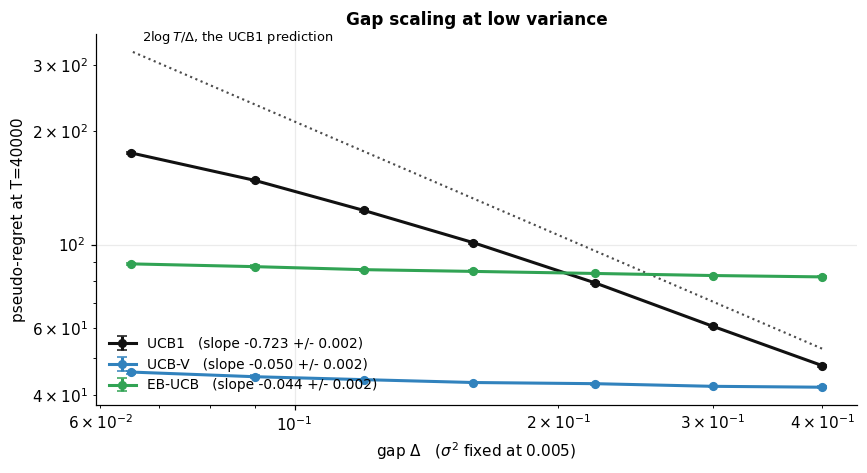

error bars are two standard errors; at R=80 they are smaller than the plot markers


In [167]:
gaps = np.array(GAPS)
lx = np.log(gaps); lxb = lx.mean(); Sxx = ((lx - lxb) ** 2).sum()

fig, ax = plt.subplots(figsize=(8, 4.4))
for cls in ALGOS:
    y, se = np.array(EC[cls.label]), np.array(ECse[cls.label])
    sl = np.polyfit(lx, np.log(y), 1)[0]
    # Standard error on the fitted slope, by propagating the per-point errors. Each gap is a
    # separate instance, so the points are independent, and se(log y) = se / y.
    sl_se = np.sqrt(((((lx - lxb) / Sxx) * se / y) ** 2).sum())
    ax.errorbar(gaps, y, yerr=2 * se, fmt="o-", ms=5, lw=2, capsize=3, color=colour(cls.label),
                label=f"{cls.label}   (slope {sl:+.3f} +/- {sl_se:.3f})")
ax.set_xscale("log"); ax.set_yscale("log")
ref = 2 * np.log(T3) / gaps
ax.plot(gaps, ref, ":", color="k", lw=1.4, alpha=0.7)
ax.annotate(r"$2\log T/\Delta$, the UCB1 prediction", (gaps[-1] * 1.03, ref[-1] * 1.06), fontsize=8.5)
ax.set_xlabel(r"gap $\Delta$   ($\sigma^2$ fixed at 0.005)")
ax.set_ylabel(f"pseudo-regret at T={T3}")
ax.set_title("Gap scaling at low variance")
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout(); plt.show()

print("error bars are two standard errors; at R=80 they are smaller than the plot markers")


UCB1's regret increases as the suboptimality gap gets smaller with a fitted log-log slope of $-0.723 \pm 0.002$, while UCB-V and EB-UCB have much shallower slopes at $-0.050 \pm 0.002$ and $-0.044 \pm 0.002$, respectively. Both still have strictly non-zero slopes as, at $R = 80$, the standard errors range from $0.1$ to $0.6$ according to the table above. This means that the increase of UCB-V from $41.9 \pm 0.1$ to $45.9 \pm 0.2$ is roughly a seperation of 18 standard errors. Over a factor of six in $\Delta$, UCB1's regret grows by $3.7\times$ while UCB-V's grows by $1.10\times$. These are two entirely different functional forms.

This also means that the neglected $2\sigma^2\mathcal{E}/\Delta$ term predicts a $1.6$ rise in regret across this sweep for UCB-V against the observed $4.0$. The range term explains the level of the regret. When $\sigma^2$ is close to 0 a bad arm is dropped once $3c\mathcal{E}/n < \Delta$, that is after $n \approx 3c\mathcal{E}/\Delta$ pulls, costing $\Delta \cdot n \approx 3c\mathcal{E}$ regret.

The cancellation gives a parameter-free numerical prediction.

In [172]:
lnT = np.log(T3)
pred = {"UCB-V":  3 * 1.2 * lnT,        # 3 c zeta log T
        "EB-UCB": (7 / 3) * 3 * lnT}    # (7b/3) * 3 log t
print(f"Horizon T={T3}, log T = {lnT:.2f}\n")
print(f"{'algorithm':<10}{'predicted':>11}{'observed (mean over gaps)':>28}{'ratio':>8}")
print("-" * 58)
for k, p in pred.items():
    obs = np.mean(EC[k])
    print(f"{k:<10}{p:11.1f}{obs:28.1f}{obs / p:8.2f}")
print("\nspread of observed regret across the gap sweep (max/min):")
for cls in ALGOS:
    y = np.array(EC[cls.label])
    print(f"  {cls.label:<8}{y.max() / y.min():5.2f}x   (the gap itself varied by {gaps.max() / gaps.min():.1f}x)")

Horizon T=40000, log T = 10.60

algorithm   predicted   observed (mean over gaps)   ratio
----------------------------------------------------------
UCB-V            38.1                        43.5    1.14
EB-UCB           74.2                        85.1    1.15

spread of observed regret across the gap sweep (max/min):
  UCB1     3.66x   (the gap itself varied by 6.2x)
  UCB-V    1.10x   (the gap itself varied by 6.2x)
  EB-UCB   1.08x   (the gap itself varied by 6.2x)


The constants $3c\zeta\log T$ and $\tfrac{7}{3}\cdot 3\log T$ are close to the measured values while the measured values themselves barely move across the sweep. These two facts are strong evidence that the range term, not the variance, is governing these algorithms in the low-variance regime.

# Part 4. Findings

### 1. UCB1's blindness to variance costs roughly an order of magnitude

Across a 120-fold sweep of the arm variance with the means held fixed, UCB1's regret moved by less than the Monte Carlo error (section 2.4). One would expect this from looking at the formula for the bound used in the algorithm, as there is no variance term in $\sqrt{\alpha\log t/n}$; however, variance would impact the noise seen in the sample mean, so the confirmation is non-trivial.

The part that was quantified and established was the size of the waste in pulls needed to shrink the confidence radius below a given target. Section 2.2 shows that about 11.3 times more pulls were needed for Hoeffding's bound to reach a confidence radius of $0.05$ at $\sigma^2 = 0.002$ compared to Bernstein's. A variance-aware method attempts to recover this waste.

### 2. Variance adaptation works, but saturates short of the theory's leading term

Although UCB-V and EB-UCB respond to variance unlike UCB1 (and UCB-V accrues less regret as a result), the fall in regret is not proportional, decreasing only by a factor of 2 across a 120 fold sweep. UCB-V outperforms UCB1, while EB-UCB does worse than UCB1 above $\sigma^2 \approx 0.02$, which shows that responding to variance and beating a variance blind baseline is not necessarily the same achievement.

Experiment B provides the reason for this: for UCB-V the two terms of the empirical Bernstein radius are equal at $n^\star = 9c^2b^2\mathcal{E}/(2\sigma^2)$, which grows as the variance falls. Since pull counts sit below $n^\star$ for almost every variance tested, the range term (which does not include the variance estimate) contributes to both algorithms significantly before a suboptimal arm is dropped. The $\sigma^2/\Delta^2$ term that makes these algorithms variance-aware is outweighed by the range term at low variances, precisely where it is needed.

### 3. The real win is a change in gap scaling, from $1/\Delta^2$ to $1/\Delta$


The findings from experiment C show that, at low variance, UCB1's regret decreases with a linear log-log slope, while UCB-V's and EB-UCB's stay within a few hundredths of flat.

The mechanism of this near flat curve is a cancellation of the delta term: a near-deterministic arm is dropped after $n \approx 3c\mathcal{E}/\Delta$ pulls, costing $\Delta \cdot n \approx 3c\mathcal{E}$ regret. The resulting parameter-free predictions, $3c\zeta\log T$ for UCB-V and $7\log T$ for EB-UCB, matched measurements closely.

The main summary of this finding is that variance adaptation does not make regret proportional to variance; rather, it lowers the exponent of the pull count from $1/\Delta^2$ to $1/\Delta$, making regret nearly independent of gap for arms that are nearly deterministic (have low variance).

### 4. Purpose of the range term

The range term cannot be simply removed to get proportional scaling with variance, as it acts as a bound that stops an observed variance of 0 from 'locking' the value of an arm in. For example, suppose the range term was removed, and in the first few pulls an arm happens to get identical draws. This would result in an observed variance of 0 and potentially render the arm unreachable for the remainder of the      run.

Audibert et al. prove this in Theorem 6, which states that with $\mathcal{E}_t = \zeta\log t$, and independently of the value of $\zeta$, if $c\zeta < 1/3$ then there exist reward distributions on which UCB-V suffers a polynomial loss instead of a logarithmic one. I set $c\zeta = 1.2$, well above the threshold; setting $c = 0$ puts the algorithm provably below it for any $\zeta$. Their Theorem 10 describes the resulting failure as a two-moded regret distribution, one mode at $\Theta(\log n)$ and one at $\Omega(\Delta^2 n)$, which is why this has to be judged on the full distribution and not on the mean.


## Limitations

- Synthetic, hand-picked instances were chosen to isolate the effect variance would have on regret. Nothing here says how often real problems have near-deterministic suboptimal arms.
- UCB-V and EB-UCB were the only two algorithms tested and both are empirical Bernstein methods, sharing a failure mode by construction. The distribution-aware family is untested here.
- I use the same constants as the ones in the cited literature. Tuning $\zeta$ or $c$ per instance would flatter UCB-V, and would be unfair unless every algorithm got the same treatment.
- Only the mean regret is reported
- The bandit is stationary, non-contextual, and has finite horizon.
- Pseudo-regret is used. It has the same expectation as realised regret but a much tighter spread, so the error bars understate the variability.


## References

- A. Slivkins. *Introduction to Multi-Armed Bandits*. Foundations and Trends in Machine Learning, 2019.
  arXiv:1904.07272v8. Sections cited: §1.1 model, §1.2 uniform exploration, §1.3 UCB1 and Successive
  Elimination, §3.1 to §3.2 Thompson sampling, Appendix A concentration inequalities.
- P. Auer, N. Cesa-Bianchi, P. Fischer. *Finite-time Analysis of the Multiarmed Bandit Problem*.
  Machine Learning 47, 2002. UCB1.
- J.-Y. Audibert, R. Munos, C. Szepesvari. *Exploration-exploitation tradeoff using variance estimates in
  multi-armed bandits*. Theoretical Computer Science 410, 2009. UCB-V.
- A. Maurer, M. Pontil. *Empirical Bernstein Bounds and Sample Variance Penalization*. COLT 2009.